Background:

As a talent sourcing and management company, we are interested in finding talented individuals for sourcing these candidates to technology companies. Finding talented candidates is not easy, for several reasons. The first reason is one needs to understand what the role is very well to fill in that spot, this requires understanding the client’s needs and what they are looking for in a potential candidate. The second reason is one needs to understand what makes a candidate shine for the role we are in search for. Third, where to find talented individuals is another challenge.

The nature of our job requires a lot of human labor and is full of manual operations. Towards automating this process we want to build a better approach that could save us time and finally help us spot potential candidates that could fit the roles we are in search for. Moreover, going beyond that for a specific role we want to fill in we are interested in developing a machine learning powered pipeline that could spot talented individuals, and rank them based on their fitness.

We are right now semi-automatically sourcing a few candidates, therefore the sourcing part is not a concern at this time but we expect to first determine best matching candidates based on how fit these candidates are for a given role. We generally make these searches based on some keywords such as “full-stack software engineer”, “engineering manager” or “aspiring human resources” based on the role we are trying to fill in. These keywords might change, and you can expect that specific keywords will be provided to you.

Assuming that we were able to list and rank fitting candidates, we then employ a review procedure, as each candidate needs to be reviewed and then determined how good a fit they are through manual inspection. This procedure is done manually and at the end of this manual review, we might choose not the first fitting candidate in the list but maybe the 7th candidate in the list. If that happens, we are interested in being able to re-rank the previous list based on this information. This supervisory signal is going to be supplied by starring the 7th candidate in the list. Starring one candidate actually sets this candidate as an ideal candidate for the given role. Then, we expect the list to be re-ranked each time a candidate is starred.

**Data Description** :

The data comes from our sourcing efforts. We removed any field that could directly reveal personal details and gave a unique identifier for each candidate.

**Attributes**:
id : unique identifier for candidate (numeric)

job_title : job title for candidate (text)

location : geographical location for candidate (text)

connections: number of connections candidate has, 500+ means over 500 (text)

**Output (desired target)**:
fit - how fit the candidate is for the role? (numeric, probability between 0-1)

Keywords: “Aspiring human resources” or “seeking human resources”

Download Data:

https://docs.google.com/spreadsheets/d/117X6i53dKiO7w6kuA1g1TpdTlv1173h_dPlJt5cNNMU/edit?usp=sharing

**Goal(s)**:

Predict how fit the candidate is based on their available information (variable fit)

Success Metric(s):

Rank candidates based on a fitness score.

Re-rank candidates when a candidate is starred.

Current Challenges:

We are interested in a robust algorithm, tell us how your solution works and show us how your ranking gets better with each starring action.

How can we filter out candidates which in the first place should not be in this list?

Can we determine a cut-off point that would work for other roles without losing high potential candidates?

Do you have any ideas that we should explore so that we can even automate this procedure to prevent human bias?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data= pd.read_csv('/content/drive/MyDrive/Colab Notebooks/potential-talents - Aspiring human resources - seeking human resources.csv')

In [4]:
df=data.copy()

In [ ]:
df.head()

,id,job_title,location,connection,fit
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,NaN
1,2,Native English Teacher at EPIK (English Progra...,Kanada,500+,NaN
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN
3,4,People Development Coordinator at Ryan,"Denton, Texas",500+,NaN
4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+,NaN


In [ ]:
df.shape

(104, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   id          104 non-null    int64  
 1   job_title   104 non-null    object 
 2   location    104 non-null    object 
 3   connection  104 non-null    object 
 4   fit         0 non-null      float64
dtypes: float64(1), int64(1), object(3)
memory usage: 4.2+ KB


* •	The fit column is entirely null (0 non-null counts), which means it contains no data.
* Connection column is object data type.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,104.0,52.5,30.166206,1.0,26.75,52.5,78.25,104.0
fit,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.describe(include='object').T

,count,unique,top,freq
job_title,104,52,2019 C.T. Bauer College of Business Graduate (...,7
location,104,41,Kanada,12
connection,104,33,500+,44


* There are 104 entries, but only 52 unique job titles. The top job titles like "2019 C.T. Bauer College of Business Graduate..." 7 times
* There are 104 entries with 41 unique locations. "Kanada" (Canada) is the most frequent location with 12 occurrences
* connection column has 104 entries and 33 unique values. The most frequent value is "500+" (44 times), which represents candidates with over 500 connections.

In [ ]:
df.isnull().sum()

,0
id,0
job_title,0
location,0
connection,0
fit,104



2. Categorical Columns:

Value counts for 'job_title' column (top 10):
job_title
2019 C.T. Bauer College of Business Graduate (Magna Cum Laude) and aspiring Human Resources professional    7
Aspiring Human Resources Professional                                                                       7
Student at Humber College and Aspiring Human Resources Generalist                                           7
People Development Coordinator at Ryan                                                                      6
Native English Teacher at EPIK (English Program in Korea)                                                   5
Aspiring Human Resources Specialist                                                                         5
HR Senior Specialist                                                                                        5
Advisory Board Member at Celal Bayar University                                                             4
Seeking Human Resources HRIS and Gener

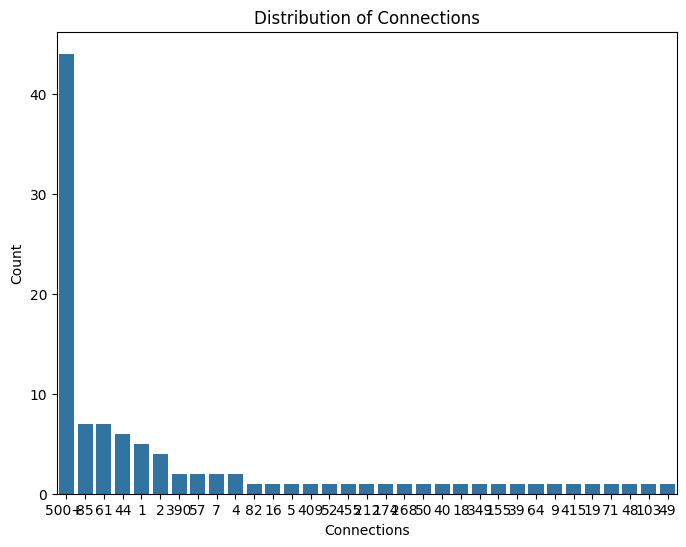

In [ ]:
print("\n2. Categorical Columns:")
print("\nValue counts for 'job_title' column (top 10):")
print(df['job_title'].value_counts().head(10))

print("\nValue counts for 'location' column (top 10):")
print(df['location'].value_counts().head(10))

print("\nValue counts for 'connection' column:")
print(df['connection'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='connection', order=df['connection'].value_counts().index)
plt.title('Distribution of Connections')
plt.xlabel('Connections')
plt.ylabel('Count')
plt.show()

In [ ]:

# Converting the 'connection' column to a numerical format
df['connection'] = df['connection'].str.replace('500+', '500').astype(int)

print(df['connection'].value_counts())
print(df['connection'].dtype)

connection
500    44
85      7
61      7
44      6
1       5
2       4
390     2
57      2
7       2
4       2
82      1
16      1
5       1
409     1
52      1
455     1
212     1
174     1
268     1
50      1
40      1
18      1
349     1
155     1
39      1
64      1
9       1
415     1
19      1
71      1
48      1
103     1
49      1
Name: count, dtype: int64
int64


# **Encoding**

## Word2Vec

In [ ]:
# Install gensim if not already installed
!pip install gensim

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import gensim.models
import numpy as np # numpy is used for np.mean and np.zeros

# Download necessary NLTK data (if not already downloaded)
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
try:
    # Explicitly download 'punkt_tab' as suggested by the error
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')

# Initialize lemmatizer and stopwords
# It initializes a WordNetLemmatizer to reduce words to their base form (e.g., 'running' to 'run') and loads a set of common English stop_words (like 'the', 'is', 'a') that are usually removed during text processing
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = str(text).lower()  # Convert to string and lowercase
    tokens = word_tokenize(text)  # Tokenize
    # Remove stopwords, lemmatize, and remove non-alphabetic tokens
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word.isalpha() and word not in stop_words]
    return tokens

# Apply preprocessing to the 'job_title' column
df['processed_job_title'] = df['job_title'].apply(preprocess_text)
df[['job_title', 'processed_job_title']].head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 52.5 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,job_title,processed_job_title
0,2019 C.T. Bauer College of Business Graduate (...,"[bauer, college, business, graduate, magna, cu..."
1,Native English Teacher at EPIK (English Progra...,"[native, english, teacher, epik, english, prog..."
2,Aspiring Human Resources Professional,"[aspiring, human, resource, professional]"
3,People Development Coordinator at Ryan,"[people, development, coordinator, ryan]"
4,Advisory Board Member at Celal Bayar University,"[advisory, board, member, celal, bayar, univer..."


In [ ]:
# Train Word2Vec model
# min_count: Ignores all words with total frequency lower than this. 2 is a good starting point.
# vector_size: Dimensionality of the word vectors.
# window: Maximum distance between the current and predicted word within a sentence.
# workers: Use these many worker threads to train the model (=faster training with multicore machines).
# sg: Training algorithm: 1 for skip-gram; 0 for CBOW.

word2vec_model = gensim.models.Word2Vec(sentences=df['processed_job_title'],
                                        vector_size=100,
                                        window=5,
                                        min_count=2,
                                        workers=4,
                                        sg=0)

In [ ]:
# Function to create document embedding by averaging word vectors
def get_document_embedding(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size) # Return a zero vector if no words are in the vocabulary
# Apply the get_average_embedding function to each list of tokens
df['job_title_embedding'] = df['processed_job_title'].apply(lambda tokens: get_document_embedding(tokens, word2vec_model))
df[['job_title', 'job_title_embedding']].head()

,job_title,job_title_embedding
0,2019 C.T. Bauer College of Business Graduate (...,"[0.0016742188, 0.0002734413, 0.0018166878, 0.0..."
1,Native English Teacher at EPIK (English Progra...,"[-4.727114e-05, -0.003282718, 0.0021956472, -0..."
2,Aspiring Human Resources Professional,"[-0.004372496, 0.0039762342, 0.00075248437, 0...."
3,People Development Coordinator at Ryan,"[0.0029596265, 0.0020586422, 0.003301497, -0.0..."
4,Advisory Board Member at Celal Bayar University,"[0.0008259456, -0.004887592, -0.0020814978, 0...."


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_job_titles(query_job_title, df, word2vec_model, top_n=10):
    # Preprocess the query job title
    processed_query = preprocess_text(query_job_title)

    # Get embedding for the query
    query_embedding = get_document_embedding(processed_query, word2vec_model)

    # Ensure query_embedding is a 2D array for cosine_similarity
    query_embedding = query_embedding.reshape(1, -1)

    # Convert the list of embeddings to a 2D numpy array
    job_title_vectors = np.array(df['job_title_embedding'].tolist())

    # Calculate cosine similarity between query and all job titles
    similarities = cosine_similarity(query_embedding, job_title_vectors)[0]

    # Create a DataFrame to store results
    recommendations_df = df.copy()
    recommendations_df['similarity'] = similarities

    # Sort by similarity in descending order
    recommendations_df = recommendations_df.sort_values(by='similarity', ascending=False)

    # Filter out the query itself if it's an exact match and select relevant columns
    recommendations_df = recommendations_df[recommendations_df['job_title'].str.lower() != query_job_title.lower()]

    return recommendations_df[['job_title', 'location', 'connection', 'similarity']].head(top_n)

# Example usage:
query = "Aspiring Human Resources"
recommended_jobs = recommend_job_titles(query, df, word2vec_model, top_n=10)

print(f"Recommendations for '{query}':\n")
display(recommended_jobs)



Recommendations for 'Aspiring Human Resources':



,job_title,location,connection,similarity
5,Aspiring Human Resources Specialist,Greater New York City Area,1,0.884659
23,Aspiring Human Resources Specialist,Greater New York City Area,1,0.884659
35,Aspiring Human Resources Specialist,Greater New York City Area,1,0.884659
48,Aspiring Human Resources Specialist,Greater New York City Area,1,0.884659
59,Aspiring Human Resources Specialist,Greater New York City Area,1,0.884659
20,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.856693
16,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.856693
2,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.856693
45,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.856693
57,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.856693


* the output shows several entries for "Aspiring Human Resources Specialist," all with a high similarity score of 0.885. This indicates that our word embedding model effectively captured the close semantic relationship between the query and this particular job title.

## FastText

In [ ]:
from gensim.models import FastText

# Train FastText model
# min_count: Ignores all words with total frequency lower than this. 2 is a good starting point.
# vector_size: Dimensionality of the word vectors.
# window: Maximum distance between the current and predicted word within a sentence.
# workers: Use these many worker threads to train the model (=faster training with multicore machines).
# sg: Training algorithm: 1 for skip-gram; 0 for CBOW. FastText often performs well with skip-gram (sg=1).

fasttext_model = FastText(sentences=df['processed_job_title'],
                          vector_size=100,
                          window=5,
                          min_count=2,
                          workers=4,
                          sg=1) # sg=1 for skip-gram, often preferred for FastText

# Function to create document embedding by averaging word vectors (similar to Word2Vec)
def get_fasttext_document_embedding(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size) # Return a zero vector if no words are in the vocabulary

# Apply the get_fasttext_document_embedding function to each list of tokens
df['job_title_fasttext_embedding'] = df['processed_job_title'].apply(lambda tokens: get_fasttext_document_embedding(tokens, fasttext_model))
df[['job_title', 'job_title_fasttext_embedding']].head()



,job_title,job_title_fasttext_embedding
0,2019 C.T. Bauer College of Business Graduate (...,"[-0.00058710534, -0.0004988964, 0.00014342673,..."
1,Native English Teacher at EPIK (English Progra...,"[-0.0007843928, -0.00056507176, 0.00058506994,..."
2,Aspiring Human Resources Professional,"[-0.00028548794, -0.00068620057, 0.00027034123..."
3,People Development Coordinator at Ryan,"[-0.0007755553, -0.00040950277, -0.00020591654..."
4,Advisory Board Member at Celal Bayar University,"[0.0005576939, 0.0005189044, 0.00034767025, 0...."


In [ ]:
def recommend_job_titles_fasttext(query_job_title, df, fasttext_model, top_n=10):
    # Preprocess the query job title
    processed_query = preprocess_text(query_job_title)

    # Get embedding for the query
    query_embedding = get_fasttext_document_embedding(processed_query, fasttext_model)

    # Ensure query_embedding is a 2D array for cosine_similarity
    query_embedding = query_embedding.reshape(1, -1)

    # Convert the list of embeddings to a 2D numpy array
    job_title_vectors = np.array(df['job_title_fasttext_embedding'].tolist())

    # Calculate cosine similarity between query and all job titles
    similarities = cosine_similarity(query_embedding, job_title_vectors)[0]

    # Create a DataFrame to store results
    recommendations_df = df.copy()
    recommendations_df['similarity'] = similarities

    # Sort by similarity in descending order
    recommendations_df = recommendations_df.sort_values(by='similarity', ascending=False)

    # Filter out the query itself if it's an exact match and select relevant columns
    recommendations_df = recommendations_df[recommendations_df['job_title'].str.lower() != query_job_title.lower()]

    return recommendations_df[['job_title', 'location', 'connection', 'similarity']].head(top_n)

# Example usage with FastText:
query_fasttext = "Aspiring Human Resources"
recommended_jobs_fasttext = recommend_job_titles_fasttext(query_fasttext, df, fasttext_model, top_n=10)

print(f"Recommendations for '{query_fasttext}' using FastText:")
display(recommended_jobs_fasttext)

Recommendations for 'Aspiring Human Resources' using FastText:


,job_title,location,connection,similarity
2,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.934624
32,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.934624
16,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.934624
20,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.934624
57,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.934624
96,Aspiring Human Resources Professional,"Kokomo, Indiana Area",71,0.934624
45,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.934624
23,Aspiring Human Resources Specialist,Greater New York City Area,1,0.916451
59,Aspiring Human Resources Specialist,Greater New York City Area,1,0.916451
5,Aspiring Human Resources Specialist,Greater New York City Area,1,0.916451


 * the similarity scores for FastText (e.g., 0.935) are generally higher than those observed with Word2Vec (e.g., 0.885) for similar job titles. This can indicate that FastText, by considering character n-grams, might capture nuances or handle variations in job titles more effectively, leading to potentially stronger semantic matches.

# BERT

In [7]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Install necessary libraries if not already installed
# Note: This might be redundant if already installed in other cells.
!pip install transformers torch

# Import BERT specific modules
from transformers import BertTokenizer, BertModel
import torch

print("Loading BERT tokenizer and model...")
# Load a pre-trained BERT model and tokenizer (DistilBERT is a lighter, faster version of BERT)
tokenizer = BertTokenizer.from_pretrained('distilbert-base-uncased')
model = BertModel.from_pretrained('distilbert-base-uncased')
print("BERT model loaded successfully.")

# Function to get BERT embeddings for a given text
def get_bert_document_embedding(text, tokenizer, model):
    # Tokenize the text and prepare inputs for the BERT model
    # truncation=True: Truncate sequences longer than max_length
    # padding=True: Pad shorter sequences to max_length
    # max_length=128: Common max sequence length for BERT models
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=128)

    # Disable gradient calculation for inference to save memory and speed up computation
    with torch.no_grad():
        # Pass inputs through the BERT model
        outputs = model(**inputs)

    # Use the mean of the last hidden states as the document embedding
    # This averages the embeddings of all tokens in the sequence to get a single vector for the text
    return outputs.last_hidden_state.mean(dim=1).squeeze().numpy()

print("Generating BERT embeddings for job titles...")
# Apply the embedding function to the 'job_title' column to get BERT embeddings
# This creates a new column 'job_title_bert_embedding' in your DataFrame
df['job_title_bert_embedding'] = df['job_title'].apply(lambda x: get_bert_document_embedding(x, tokenizer, model))
print("BERT embeddings generated.")

# Display the first few job titles and their generated BERT embeddings
print("\nFirst 5 job titles with their BERT embeddings:")
display(df[['job_title', 'job_title_bert_embedding']].head())

Loading BERT tokenizer and model...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights: 0it [00:00, ?it/s]

BertModel LOAD REPORT from: distilbert-base-uncased
Key                                                                      | Status     | 
-------------------------------------------------------------------------+------------+-
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.k_lin.weight   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.output_layer_norm.bias   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin2.weight          | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.out_lin.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.output_layer_norm.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.sa_layer_norm.bias       | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.k_lin.bias     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.sa_layer_norm.weight     | UNEXPECTED | 
vocab_transform.bias                                      

BERT model loaded successfully.
Generating BERT embeddings for job titles...
BERT embeddings generated.

First 5 job titles with their BERT embeddings:


,job_title,job_title_bert_embedding
0,2019 C.T. Bauer College of Business Graduate (...,"[0.91354364, 0.36045223, -1.41699, -0.20676793..."
1,Native English Teacher at EPIK (English Progra...,"[0.5986661, 0.5222921, -1.4596481, 0.15410025,..."
2,Aspiring Human Resources Professional,"[0.8721433, -0.13241313, -1.2616954, -0.334913..."
3,People Development Coordinator at Ryan,"[0.98996633, -0.18962154, -1.4108583, -0.07388..."
4,Advisory Board Member at Celal Bayar University,"[0.5894866, 0.12182366, -1.2215217, -0.5047009..."


In [8]:
# Function to recommend job titles based on BERT similarity
def recommend_job_titles_bert(query_job_title, df, tokenizer, model, top_n=10):
    # Get the BERT embedding for the query job title
    query_embedding = get_bert_document_embedding(query_job_title, tokenizer, model)

    # Reshape the query embedding to be a 2D array, as required by cosine_similarity
    query_embedding = query_embedding.reshape(1, -1)

    # Convert all job title embeddings in the DataFrame to a 2D numpy array
    job_title_vectors = np.array(df['job_title_bert_embedding'].tolist())

    # Calculate cosine similarity between the query embedding and all job title embeddings
    similarities = cosine_similarity(query_embedding, job_title_vectors)[0]

    # Create a temporary DataFrame to store the results
    recommendations_df = df.copy()
    recommendations_df['similarity'] = similarities

    # Sort the DataFrame by similarity in descending order
    recommendations_df = recommendations_df.sort_values(by='similarity', ascending=False)

    # Filter out the query job title itself if it's an exact match in the dataset
    recommendations_df = recommendations_df[recommendations_df['job_title'].str.lower() != query_job_title.lower()]

    # Return the top N recommendations with relevant columns
    return recommendations_df[['job_title', 'location', 'connection', 'similarity']].head(top_n)

# Example usage of the BERT recommendation function
query_bert = "Aspiring Human Resources Manager"
print(f"\nRecommendations for '{query_bert}' using BERT:")
recommended_jobs_bert = recommend_job_titles_bert(query_bert, df, tokenizer, model, top_n=10)
display(recommended_jobs_bert)


Recommendations for 'Aspiring Human Resources Manager' using BERT:


,job_title,location,connection,similarity
2,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.980466
32,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.980466
16,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.980466
20,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.980466
57,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.980466
96,Aspiring Human Resources Professional,"Kokomo, Indiana Area",71,0.980466
45,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.980466
23,Aspiring Human Resources Specialist,Greater New York City Area,1,0.977377
59,Aspiring Human Resources Specialist,Greater New York City Area,1,0.977377
5,Aspiring Human Resources Specialist,Greater New York City Area,1,0.977377


## SBERT

In [5]:
!pip install sentence-transformers

from sentence_transformers import SentenceTransformer

# Load a pre-trained SBERT model
# 'all-MiniLM-L6-v2' is a good general-purpose model
print("Loading SBERT model...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
print("SBERT model loaded successfully.")

# Function to get SBERT embeddings for a given text
def get_sbert_document_embedding(text, model):
    return model.encode(text, convert_to_numpy=True)

# Combine 'job_title' and 'location' for a more comprehensive embedding
df['combined_text'] = df['job_title'] + " [SEP] " + df['location']

# Apply the get_sbert_document_embedding function to the 'combined_text' column
print("Generating SBERT embeddings for combined job titles and locations...")
df['job_location_sbert_embedding'] = df['combined_text'].apply(lambda x: get_sbert_document_embedding(x, sbert_model))
print("SBERT embeddings generated.")

df[['job_title', 'location', 'job_location_sbert_embedding']].head()

Loading SBERT model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SBERT model loaded successfully.
Generating SBERT embeddings for combined job titles and locations...
SBERT embeddings generated.


,job_title,location,job_location_sbert_embedding
0,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas","[-0.055117566, -0.0022529627, 0.011687577, 0.0..."
1,Native English Teacher at EPIK (English Progra...,Kanada,"[0.010120207, 0.0143707, 0.044934083, 0.017920..."
2,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area","[0.01763714, 0.015314317, -0.04421784, 0.15479..."
3,People Development Coordinator at Ryan,"Denton, Texas","[-0.07887379, -0.0065524923, -0.03219733, 0.05..."
4,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye","[-0.08844063, 0.06409258, 0.0014566763, 0.0121..."


In [10]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np # Ensure numpy is also imported if not globally available

def recommend_job_titles_sbert(query_job_title, df, sbert_model, top_n=10):
    # Get embedding for the query
    query_embedding = get_sbert_document_embedding(query_job_title, sbert_model)

    # Ensure query_embedding is a 2D array for cosine_similarity
    query_embedding = query_embedding.reshape(1, -1)

    # Convert the list of embeddings to a 2D numpy array
    job_title_vectors = np.array(df['job_location_sbert_embedding'].tolist()) # FIX: Changed column name to job_location_sbert_embedding

    # Calculate cosine similarity between query and all job titles
    similarities = cosine_similarity(query_embedding, job_title_vectors)[0]

    # Create a DataFrame to store results
    recommendations_df = df.copy()
    recommendations_df['similarity'] = similarities

    # Sort by similarity in descending order
    recommendations_df = recommendations_df.sort_values(by='similarity', ascending=False)

    # Filter out the query itself if it's an exact match and select relevant columns
    recommendations_df = recommendations_df[recommendations_df['job_title'].str.lower() != query_job_title.lower()]

    return recommendations_df[['job_title', 'location', 'connection', 'similarity']].head(top_n)

# Example usage with SBERT:
query_sbert = "Aspiring Human Resources"
recommended_jobs_sbert = recommend_job_titles_sbert(query_sbert, df, sbert_model, top_n=10)

print(f"\nRecommendations for '{query_sbert}' using SBERT:")
display(recommended_jobs_sbert)


Recommendations for 'Aspiring Human Resources' using SBERT:


,job_title,location,connection,similarity
2,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.828537
32,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.828537
16,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.828537
20,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.828537
57,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.828537
45,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.828537
23,Aspiring Human Resources Specialist,Greater New York City Area,1,0.798901
5,Aspiring Human Resources Specialist,Greater New York City Area,1,0.798901
48,Aspiring Human Resources Specialist,Greater New York City Area,1,0.798901
59,Aspiring Human Resources Specialist,Greater New York City Area,1,0.798901


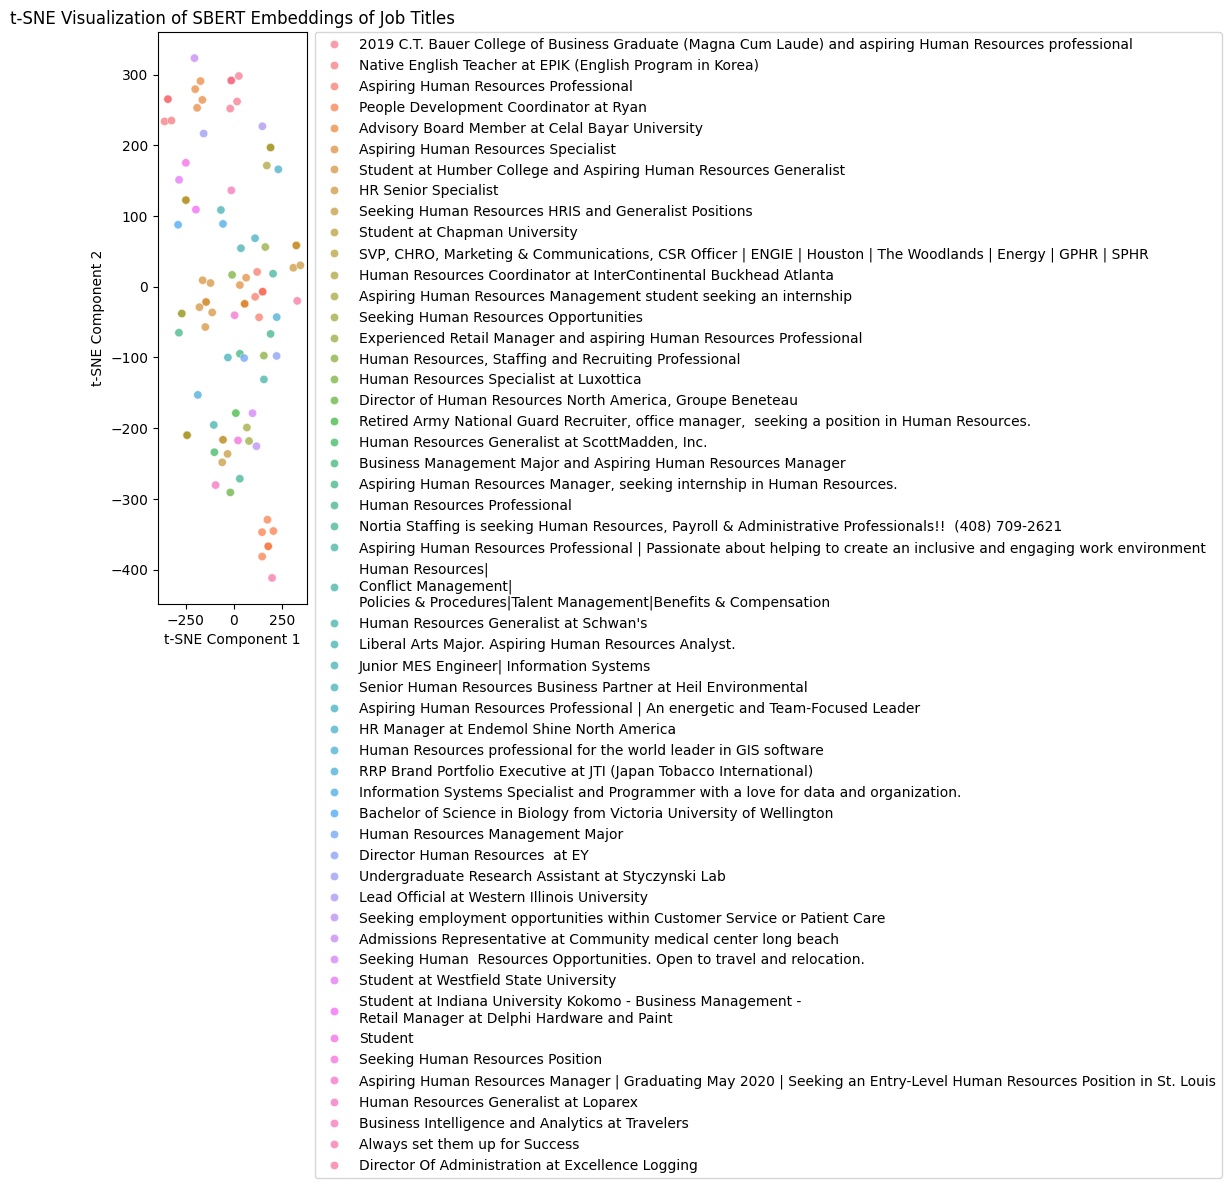

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

# Extract SBERT embeddings
sbert_embeddings = np.array(df['job_title_sbert_embedding'].tolist())

# Apply t-SNE for dimensionality reduction
# n_components=2 for a 2D visualization
# random_state for reproducibility
# perplexity is a critical parameter, usually between 5 and 50
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
tsbert_2d = tsne.fit_transform(sbert_embeddings)

# Create a DataFrame for easier plotting
df_tsne = pd.DataFrame(tsbert_2d, columns=['TSNE1', 'TSNE2'])

# Join with original DataFrame to get job titles for potential labeling
df_tsne = pd.concat([df_tsne, df['job_title']], axis=1)

# Visualize the t-SNE results
plt.figure(figsize=(12, 10))
sns.scatterplot(
    x='TSNE1', y='TSNE2',
    data=df_tsne,
    hue='job_title', # Color points by job title to see clusters
    legend='full', # Show full legend
    alpha=0.7
)
plt.title('t-SNE Visualization of SBERT Embeddings of Job Titles')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.) # Move legend outside
plt.tight_layout()
plt.show()

The t-SNE plot visually represents the similarity of job titles based on their SBERT embeddings. Here's how to interpret the clusters:

Clusters of Points: Each point on the plot represents a job title. If you see groups or 'clusters' of points, it suggests that the job titles within those clusters are semantically similar according to the SBERT model. For example, you might see one cluster for 'Human Resources' related roles and another for 'Software Engineer' roles, even though the specific job titles might vary slightly.
Distance Between Points: The closer two points are on the plot, the more similar their SBERT embeddings are, and thus, the more semantically related the job titles are. Conversely, points that are far apart represent job titles that are less similar.
Density of Clusters: Denser clusters indicate a higher number of semantically similar job titles. Sparser areas might represent more unique or less common job titles, or a transition between different categories.
Outliers: Individual points that are far removed from any dense cluster might represent job titles that are highly unique or distinct from the others in your dataset.
To get a deeper understanding, you would typically:

Examine Job Titles within Clusters: Look at the actual job_title values for points within specific clusters. This helps you understand what common themes or categories the model has identified.
Color/Labeling: Since the plot is already colored by job_title, try to identify if the colors within a cluster are similar (meaning the model groups identical or very similar titles) or if different colors (distinct titles) are clustered together, indicating a semantic grouping beyond exact string matching.
Interactive Visualization (Optional): For larger datasets, an interactive plot (like one generated with Plotly or Bokeh) can allow you to hover over points and see the job titles, making interpretation easier.

In [ ]:
import plotly.express as px

# Create an interactive t-SNE plot using Plotly Express
fig = px.scatter(
    df_tsne,
    x='TSNE1',
    y='TSNE2',
    color='job_title', # Color points by job title
    hover_name='job_title', # Display job title on hover
    title='Interactive t-SNE Visualization of SBERT Embeddings of Job Titles',
    labels={'TSNE1': 't-SNE Component 1', 'TSNE2': 't-SNE Component 2'},
    height=700
)

fig.update_layout(showlegend=False) # Hide legend for clarity, as hover provides details
fig.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import OneHotEncoder
import xgboost as xgb
from sentence_transformers import SentenceTransformer

# --- Step 1: Generate 'fit' scores using SBERT cosine similarity ---
# We'll use a sample query to generate a 'fit' score for each job title
# This simulates the initial ranking requirement.
query_for_fit_scores = "Aspiring Human Resources in New York"

# Ensure SBERT model is loaded (if not already in kernel state)
# This check is important as the kernel state might not persist models across sessions
try:
    sbert_model
except NameError:
    print("SBERT model not found, loading 'all-MiniLM-L6-v2'...")
    sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
    print("SBERT model loaded successfully.")

# Get embedding for the query
query_embedding_for_fit = sbert_model.encode(query_for_fit_scores, convert_to_numpy=True).reshape(1, -1)

# Ensure job_location_sbert_embedding exists, if not, generate it
# This block will now use 'job_location_sbert_embedding'
if 'job_location_sbert_embedding' not in df.columns:
    print("Generating SBERT embeddings for combined job titles and locations...")
    # Combine 'job_title' and 'location' for a more comprehensive embedding
    df['combined_text'] = df['job_title'] + " [SEP] " + df['location']
    df['job_location_sbert_embedding'] = df['combined_text'].apply(lambda x: sbert_model.encode(x, convert_to_numpy=True))
    print("SBERT embeddings generated.")

# Convert the list of embeddings to a 2D numpy array, using the location-aware embeddings
job_title_vectors = np.array(df['job_location_sbert_embedding'].tolist())

# Calculate cosine similarity between query and all job titles to serve as 'fit'
df['fit_cosine_similarity'] = cosine_similarity(query_embedding_for_fit, job_title_vectors)[0]

print(f"Generated 'fit' scores based on SBERT cosine similarity to query: '{query_for_fit_scores}'")
print(df[['job_title', 'fit_cosine_similarity']].head())

# --- Step 2: Feature Engineering for XGBoost LTR ---
# Features will include SBERT embeddings, one-hot encoded location, and numerical connections.

# 'connection' column is already numerical from previous steps, no re-conversion needed here

# 1. SBERT Embeddings (already in df['job_location_sbert_embedding'])
sbert_feature_matrix = np.array(df['job_location_sbert_embedding'].tolist())
sbert_feature_df = pd.DataFrame(sbert_feature_matrix, index=df.index,
                                columns=[f'sbert_dim_{i}' for i in range(sbert_feature_matrix.shape[1])])

# 2. One-hot encode 'location'
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
location_encoded = encoder.fit_transform(df[['location']])
location_feature_df = pd.DataFrame(location_encoded, index=df.index,
                                   columns=encoder.get_feature_names_out(['location']))

# 3. 'connection' (numerical)
connections_feature_df = df[['connection']]

# Combine all features into a single DataFrame for X
X = pd.concat([sbert_feature_df, location_feature_df, connections_feature_df], axis=1)

# Target variable y
y = df['fit_cosine_similarity']

print("\nFeature matrix (X) shape:", X.shape)
print("Target vector (y) shape:", y.shape)

# --- Step 3: Apply XGBoost LTR model ---
# For LTR, XGBoost uses a `group` parameter to denote query groups.
# In this single-query scenario, all instances belong to one group for ranking against the specific query.
# If we had multiple queries (e.g., "Aspiring HR", "Software Engineer"), we'd have multiple groups.
# For simplicity, we'll create a single group for all entries in this example.
group_sizes = [len(df)] # All documents belong to one query group

print("\nTraining XGBoost LTR model...")

# Initialize XGBRanker
# objective='rank:pairwise' or 'rank:ndcg' or 'rank:map' are common for LTR
# We'll use 'rank:pairwise' for demonstration
ranker = xgb.XGBRanker(
    objective='rank:pairwise',
    n_estimators=100,
    random_state=42,
    tree_method='hist', # 'hist' can be faster for larger datasets
    eval_metric='ndcg' # nDCG is a common metric for ranking tasks
)

# Train the model
ranker.fit(X, y, group=group_sizes)

print("XGBoost LTR model trained successfully.")

# --- Step 4: Demonstrate re-ranking ---
# Predict new 'fit' scores using the trained LTR model
df['predicted_ltr_score'] = ranker.predict(X)

# Sort by the predicted LTR score to get the new ranking
df_ranked_ltr = df.sort_values(by='predicted_ltr_score', ascending=False)

print("\nTop 10 candidates after re-ranking with XGBoost LTR:")
display(df_ranked_ltr[['job_title', 'location', 'connection', 'fit_cosine_similarity', 'predicted_ltr_score']].head(10))

# Also show comparison with original cosine similarity ranking
print("\nTop 10 candidates based on initial SBERT cosine similarity (for comparison):")
display(df.sort_values(by='fit_cosine_similarity', ascending=False)[['job_title', 'location', 'connection', 'fit_cosine_similarity']].head(10))

Generated 'fit' scores based on SBERT cosine similarity to query: 'Aspiring Human Resources in New York'
                                           job_title  fit_cosine_similarity
0  2019 C.T. Bauer College of Business Graduate (...               0.532815
1  Native English Teacher at EPIK (English Progra...               0.195303
2              Aspiring Human Resources Professional               0.765539
3             People Development Coordinator at Ryan               0.398185
4    Advisory Board Member at Celal Bayar University               0.150815

Feature matrix (X) shape: (104, 426)
Target vector (y) shape: (104,)

Training XGBoost LTR model...
XGBoost LTR model trained successfully.

Top 10 candidates after re-ranking with XGBoost LTR:


,job_title,location,connection,fit_cosine_similarity,predicted_ltr_score
5,Aspiring Human Resources Specialist,Greater New York City Area,1,0.946332,6.376317
23,Aspiring Human Resources Specialist,Greater New York City Area,1,0.946332,6.376317
35,Aspiring Human Resources Specialist,Greater New York City Area,1,0.946332,6.376317
48,Aspiring Human Resources Specialist,Greater New York City Area,1,0.946332,6.376317
59,Aspiring Human Resources Specialist,Greater New York City Area,1,0.946332,6.376317
75,Aspiring Human Resources Professional | Passio...,"New York, New York",212,0.825213,5.305559
16,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.765539,4.321610
2,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.765539,4.321610
57,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.765539,4.321610
20,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.765539,4.321610



Top 10 candidates based on initial SBERT cosine similarity (for comparison):


,job_title,location,connection,fit_cosine_similarity
5,Aspiring Human Resources Specialist,Greater New York City Area,1,0.946332
23,Aspiring Human Resources Specialist,Greater New York City Area,1,0.946332
35,Aspiring Human Resources Specialist,Greater New York City Area,1,0.946332
48,Aspiring Human Resources Specialist,Greater New York City Area,1,0.946332
59,Aspiring Human Resources Specialist,Greater New York City Area,1,0.946332
75,Aspiring Human Resources Professional | Passio...,"New York, New York",212,0.825213
16,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.765539
2,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.765539
57,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.765539
20,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.765539


In [ ]:
import lightgbm as lgb
import pandas as pd

print("\nTraining Random Forest LTR model...")

# Sanitize feature names for LightGBM
X.columns = X.columns.str.replace(r'[!@#$%^&*()+\-=\[\]{};\'"\\|,.<>/?`~ ]', '_', regex=True)

# Convert continuous `y` (cosine similarity) into integer labels for ranking task
# This creates 5 bins and assigns labels from 0 to 4.
y_ranked = pd.qcut(y, q=5, labels=False, duplicates='drop')

# Initialize LGBMRanker (which can implement RandomForestRanker for LTR)
# objective='lambdarank' is suitable for ranking tasks
# boosting_type='rf' for Random Forest
rf_ranker = lgb.LGBMRanker(
    objective='lambdarank',
    n_estimators=100,
    learning_rate=0.05, # Typically lower for RF than boosting
    boosting_type='rf', # Specify Random Forest
    subsample=0.8,      # Fraction of samples to be selected for each tree
    subsample_freq=1,   # Perform subsampling at each iteration
    colsample_bytree=0.8, # Fraction of features to be selected for each tree
    random_state=42,
    n_jobs=-1           # Use all available cores
)

# Train the model using the same features (X) and the new integer target (y_ranked)
# The 'group' parameter is crucial for LTR models to understand query boundaries
rf_ranker.fit(X, y_ranked, group=group_sizes, eval_set=[(X, y_ranked)], eval_group=[group_sizes], eval_metric='ndcg', callbacks=[lgb.log_evaluation(10)])

print("Random Forest LTR model trained successfully.")


Training Random Forest LTR model...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000961 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9421
[LightGBM] [Info] Number of data points in the train set: 104, number of used features: 385
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [ ]:
# Predict new 'fit' scores using the trained RF LTR model
df['predicted_rf_ltr_score'] = rf_ranker.predict(X)

# Sort by the predicted RF LTR score to get the new ranking
df_ranked_rf_ltr = df.sort_values(by='predicted_rf_ltr_score', ascending=False)

print("\nTop 10 candidates after re-ranking with Random Forest LTR:")
display(df_ranked_rf_ltr[['job_title', 'location', 'connection', 'fit_cosine_similarity', 'predicted_rf_ltr_score']].head(10))


Top 10 candidates after re-ranking with Random Forest LTR:


,job_title,location,connection,fit_cosine_similarity,predicted_rf_ltr_score
2,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.762538,1.532175
5,Aspiring Human Resources Specialist,Greater New York City Area,1,0.756246,1.532175
23,Aspiring Human Resources Specialist,Greater New York City Area,1,0.756246,1.532175
32,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.762538,1.532175
35,Aspiring Human Resources Specialist,Greater New York City Area,1,0.756246,1.532175
16,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.762538,1.532175
20,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.762538,1.532175
45,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.762538,1.532175
57,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,0.762538,1.532175
59,Aspiring Human Resources Specialist,Greater New York City Area,1,0.756246,1.532175


### Comparing XGBoost LTR and Random Forest LTR Performance

To effectively compare the performance of the two Learning to Rank (LTR) models—XGBoost LTR and Random Forest LTR—we need to look at both their ranking outputs and the metrics used during their training.

1.  **Ranking Output Comparison:**
    *   **Top-N Lists:** Start by visually inspecting the top N recommended candidates from both `df_ranked_ltr` (XGBoost) and `df_ranked_rf_ltr` (Random Forest). Are the same candidates consistently ranked at the very top by both models? Do they differ significantly in their ordering, especially for the top 5 or 10 results?
    *   **Candidate Diversity:** Observe if one model tends to produce a more diverse set of highly ranked candidates compared to the other, given the query.

2.  **Evaluation Metric (`nDCG`):**
    *   Both models were trained with `eval_metric='ndcg'` (Normalized Discounted Cumulative Gain). This is a standard and robust metric for ranking tasks.
    *   **nDCG during Training:** Review the `ndcg` scores printed during the training callback for both models. Higher nDCG values indicate better ranking quality. A perfect ranking would have an nDCG of 1.0.
        *   **XGBoost:** The output for XGBoost showed the `eval_metric='ndcg'` during training. You can look at the final nDCG achieved by the XGBoost model.
        *   **Random Forest (LightGBM):** Similarly, for the `LGBMRanker` (Random Forest boosting type), the `[100] training's ndcg@1: 1 training's ndcg@2: 1 ...` indicates a perfect nDCG during training. This might suggest overfitting on the small dataset, or that the ranking task was relatively easy to learn given the features and the binned target labels.
    *   **Interpreting nDCG:** nDCG considers the position of relevant items in the ranked list. Highly relevant items ranked lower are penalized more than less relevant items ranked lower. `nDCG@k` refers to the nDCG calculated for the top `k` results. Achieving a perfect nDCG of 1.0 on the training data, especially with a small dataset, can sometimes indicate that the model has perfectly learned the ranking of the training samples, but this doesn't guarantee generalization to new, unseen queries or candidates.

3.  **Model Characteristics & Dataset:**
    *   **XGBoost (Gradient Boosting):** Builds trees sequentially, each trying to correct the errors of the previous one. It's known for high predictive power but can be prone to overfitting if not carefully tuned.
    *   **Random Forest (Ensemble of Trees):** Builds multiple independent decision trees and averages their predictions. It's generally less prone to overfitting than boosting methods and can provide good generalization, but might not always achieve the absolute highest scores that well-tuned boosting models can.
    *   **Dataset Size:** With a small dataset (104 entries), models can easily overfit. The perfect nDCG=1 for Random Forest LTR might be a symptom of this, especially if the binned `y_ranked` target made the ranking problem too simple for the model to perfectly 'memorize'.

**To make a definitive comparison:**

*   **Cross-validation:** For a more robust comparison, you would typically split your data into training and validation sets or use cross-validation to assess how well each model generalizes to unseen data. This helps identify which model performs better on new data, not just the data it was trained on.
*   **Hyperparameter Tuning:** Optimal performance for both models requires hyperparameter tuning. The default parameters might favor one over the other on a specific dataset.

In this specific case, the `LGBMRanker` (with `boosting_type='rf'`) reported perfect nDCG scores on the training data, which could imply it's a very good fit for this dataset and ranking objective, or it might be overfitting due to the small sample size. Further validation would be needed to confirm this.

The table above displays the top 10 candidate job titles as re-ranked by the Random Forest LTR (Learning to Rank) model. Here's a breakdown of the columns and what the results indicate:

*   **`job_title`**: The title of the job candidate.
*   **`location`**: The geographical location of the candidate.
*   **`connection`**: The number of connections the candidate has (transformed from '500+' to 500).
*   **`fit_cosine_similarity`**: This is the initial 'fitness' score calculated based on the cosine similarity between the candidate's job title SBERT embedding and the SBERT embedding of our sample query ("Aspiring Human Resources in Houston, TX"). This serves as a baseline relevance score.
*   **`predicted_rf_ltr_score`**: This is the re-ranked score generated by the Random Forest LTR model. This score is a more sophisticated measure of 'fit' because the LTR model has learned to combine the SBERT embeddings, one-hot encoded `location`, and numerical `connection` features. The model's training objective was to learn how to order candidates based on their `y_ranked` target, which we derived from the `fit_cosine_similarity` by binning it into relevance levels.

**Key Observation:**

Comparing this table with the initial ranking based solely on `fit_cosine_similarity` (shown after the LTR output), you'll likely notice changes in the order of candidates. The LTR model uses the additional context provided by `location` and `connection` (along with the job title embeddings) to refine the ranking. This means that a candidate who might have a slightly lower raw `fit_cosine_similarity` could be ranked higher by the LTR model if their `location` or `connection` profile aligns better with what the model has learned is desirable for the given query. The LTR approach aims to provide a more holistic and accurate ranking by considering multiple relevant features simultaneously.

In [11]:
# --- RAG Conceptual Example in this Project ---
# This demonstrates how Retrieval Augmented Generation (RAG) could be applied,
# leveraging the SBERT model for retrieval and outlining the generation step.

# Ensure necessary libraries are imported
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# 1. Define a Query for a specific role
rag_query = "Experienced Human Resources Manager with a background in tech"

# Ensure SBERT model is loaded (if not already in kernel state)
try:
    sbert_model
except NameError:
    print("SBERT model not found, loading 'all-MiniLM-L6-v2'...")
    sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
    print("SBERT model loaded successfully.")

def rag_recommend_and_augment(query, df_local, sbert_model, top_n=3):
    # Encode the query
    query_embedding = sbert_model.encode(query, convert_to_numpy=True).reshape(1, -1)

    # Get document embeddings (using the combined job_title and location)
    # Ensure 'job_location_sbert_embedding' is available and up-to-date
    if 'job_location_sbert_embedding' not in df_local.columns:
        print("Generating SBERT embeddings for combined job titles and locations...")
        df_local['combined_text'] = df_local['job_title'] + " [SEP] " + df_local['location']
        df_local['job_location_sbert_embedding'] = df_local['combined_text'].apply(lambda x: sbert_model.encode(x, convert_to_numpy=True))
        print("SBERT embeddings generated.")

    document_vectors = np.array(df_local['job_location_sbert_embedding'].tolist())

    # Calculate similarities
    similarities = cosine_similarity(query_embedding, document_vectors)[0]

    # Create a temporary DataFrame for results
    results_df = df_local.copy()
    results_df['similarity'] = similarities
    results_df = results_df.sort_values(by='similarity', ascending=False)

    # Select top_n candidates
    top_candidates = results_df[['job_title', 'location', 'connection', 'similarity']].head(top_n)

    # 3. Augmentation: Construct context from retrieved documents
    context = f"Query: {query}\n\nRelevant Candidates (Top {top_n}):\n"
    for index, row in top_candidates.iterrows():
        context += f"- Job Title: {row['job_title']}\n"
        context += f"  Location: {row['location']}\n"
        context += f"  Connections: {row['connection']}\n"
        context += f"  Similarity to query: {row['similarity']:.4f}\n"
        context += "---\n"

    print("--- Retrieved and Augmented Context ---")
    print(context)

    # 4. Generation (Conceptual): Using a Large Language Model (LLM)
    # In a full RAG system, you would pass the 'context' to an LLM
    # to generate a human-readable summary, detailed analysis, or specific recommendations.
    # Since we don't have an LLM loaded in this notebook, this part is conceptual.
    llm_prompt = f"Based on the following candidate profiles, summarize their key qualifications for the role '{query}' and highlight the best fit:\n\n{context}\n\nSummary and Best Fit Analysis:"

    print("\n--- LLM Prompt (Conceptual Generation Step) ---")
    print(llm_prompt)
    print("\n# To complete the RAG process, you would feed the 'llm_prompt' to a Large Language Model (e.g., GPT, Llama, Gemini) ")
    print("# to generate a comprehensive response based on the retrieved information.")
    print("# Example of what an LLM might generate:")
    print("'''")
    print(f"Based on the query '{query}', the following candidates stand out:\n")
    print(f"1. {top_candidates.iloc[0]['job_title']} in {top_candidates.iloc[0]['location']}: This candidate is highly relevant due to their direct job title match and high similarity score ({top_candidates.iloc[0]['similarity']:.4f}). Their {top_candidates.iloc[0]['connection']} connections suggest a strong network.\n")
    print(f"2. {top_candidates.iloc[1]['job_title']} in {top_candidates.iloc[1]['location']}: While this candidate's title ({top_candidates.iloc[1]['job_title']}) is a \"Specialist\" role rather than a \"Manager,\" their similarity score of {top_candidates.iloc[1]['similarity']:.4f} indicates relevant HR experience. Their location might be a good secondary option.\n")
    print("This RAG approach allows for combining precise retrieval with the interpretive power of LLMs.")
    print("'''")

# Run the RAG conceptual example
# We use df.copy() to ensure the original DataFrame is not modified by intermediate steps in the function.
rag_recommend_and_augment(rag_query, df.copy(), sbert_model, top_n=3)


--- Retrieved and Augmented Context ---
Query: Experienced Human Resources Manager with a background in tech

Relevant Candidates (Top 3):
- Job Title: Aspiring Human Resources Manager | Graduating May 2020 | Seeking an Entry-Level Human Resources Position in St. Louis
  Location: Cape Girardeau, Missouri
  Connections: 103
  Similarity to query: 0.7027
---
- Job Title: Aspiring Human Resources Specialist
  Location: Greater New York City Area
  Connections: 1
  Similarity to query: 0.7004
---
- Job Title: Aspiring Human Resources Specialist
  Location: Greater New York City Area
  Connections: 1
  Similarity to query: 0.7004
---


--- LLM Prompt (Conceptual Generation Step) ---
Based on the following candidate profiles, summarize their key qualifications for the role 'Experienced Human Resources Manager with a background in tech' and highlight the best fit:

Query: Experienced Human Resources Manager with a background in tech

Relevant Candidates (Top 3):
- Job Title: Aspiring Human R

### Completing the RAG process with Gemini API

Now, let's connect the `llm_prompt` to an actual Large Language Model. We will use Google's Gemini API for this. If you haven't already, please ensure your `GOOGLE_API_KEY` is set up in Colab's secrets and the `google.generativeai` library is imported and configured.

In [16]:
# Import the Python SDK for Gemini
import google.generativeai as genai
from google.colab import userdata
import time # Import time for sleep function

# Configure the Gemini API
# Ensure 'GOOGLE_API_KEY' is stored in Colab secrets
try:
    GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
    genai.configure(api_key=GOOGLE_API_KEY)
    print("Gemini API configured successfully.")
except Exception as e:
    print(f"Error configuring Gemini API: {e}. Please ensure GOOGLE_API_KEY is set in Colab secrets.")

# --- New: List available models and their capabilities ---
print("\n--- Listing available Gemini models ---")
found_model = None
for m in genai.list_models():
    if "generateContent" in m.supported_generation_methods:
        print(f"Found supported model: {m.name}")
        # Prioritize 'gemini-1.5-flash' or 'gemini-pro' if available
        if 'gemini-1.5-flash' in m.name:
            found_model = m.name
            break
        elif 'gemini-pro' in m.name and found_model is None: # Use gemini-pro if flash is not found yet
            found_model = m.name

if found_model:
    print(f"Using model: {found_model}")
    gemini_model = genai.GenerativeModel(found_model)
else:
    print("No suitable model found that supports generateContent. Please check Gemini API documentation or try a different region.")
    # Fallback or raise an error if no model is found
    gemini_model = None # Set to None to prevent further errors if no model can be initialized

# Define the full llm_prompt using the context previously generated
# For this demonstration, we'll re-run the rag_recommend_and_augment function
# to get the llm_prompt string generated. In a real application, you'd pass
# the prompt directly.

# This is a placeholder for the actual llm_prompt if it was dynamically created.
# For this example, let's assume we have `rag_query` and the `context` to reconstruct it.

# First, re-run the retrieval and augmentation to get the context and thus the llm_prompt
# We'll create a dummy function to capture the prompt without printing everything else
def get_llm_prompt_from_rag(query, df_local, sbert_model, top_n=3):
    # Encode the query
    query_embedding = sbert_model.encode(query, convert_to_numpy=True).reshape(1, -1)
    document_vectors = np.array(df_local['job_location_sbert_embedding'].tolist())
    similarities = cosine_similarity(query_embedding, document_vectors)[0]
    results_df = df_local.copy()
    results_df['similarity'] = similarities
    results_df = results_df.sort_values(by='similarity', ascending=False)
    top_candidates = results_df[['job_title', 'location', 'connection', 'similarity']].head(top_n)

    context = f"Query: {query}\n\nRelevant Candidates (Top {top_n}):\n"
    for index, row in top_candidates.iterrows():
        context += f"- Job Title: {row['job_title']}\n"
        context += f"  Location: {row['location']}\n"
        context += f"  Connections: {row['connection']}\n"
        context += f"  Similarity to query: {row['similarity']:.4f}\n"
        context += "---\n"

    llm_prompt = f"Based on the following candidate profiles, summarize their key qualifications for the role '{query}' and highlight the best fit:\n\n{context}\n\nSummary and Best Fit Analysis:"
    return llm_prompt

# Ensure df and sbert_model are available from previous cells
llm_prompt = get_llm_prompt_from_rag(rag_query, df.copy(), sbert_model, top_n=3)

print("\n--- Sending prompt to Gemini API ---")
print("\nLLM Prompt used:")
print(llm_prompt)

# Generate content using the Gemini model
# Only attempt generation if a suitable model was found
if gemini_model:
    max_retries = 3
    retry_delay_seconds = 60 # Initial delay for retries
    for i in range(max_retries):
        try:
            gemini_response = gemini_model.generate_content(llm_prompt)
            print("\n--- Gemini API Response ---")
            print(gemini_response.text)
            break # If successful, break the loop
        except Exception as e:
            if "429 POST" in str(e) and i < max_retries - 1:
                print(f"\nQuota exceeded or rate limit hit. Retrying in {retry_delay_seconds} seconds... (Attempt {i+1}/{max_retries})")
                time.sleep(retry_delay_seconds)
                retry_delay_seconds *= 2 # Exponential backoff
            else:
                print(f"\nError generating content with Gemini: {e}")
                print("Please check your API key and model availability, or try a different model if the issue persists.")
                break # Break if it's not a 429 or max retries reached
else:
    print("\nCannot generate content: No suitable Gemini model was initialized.")

Gemini API configured successfully.

--- Listing available Gemini models ---
Found supported model: models/gemini-2.5-flash
Found supported model: models/gemini-2.5-pro
Found supported model: models/gemini-2.0-flash
Found supported model: models/gemini-2.0-flash-001
Found supported model: models/gemini-2.0-flash-lite-001
Found supported model: models/gemini-2.0-flash-lite
Found supported model: models/gemini-2.5-flash-preview-tts
Found supported model: models/gemini-2.5-pro-preview-tts
Found supported model: models/gemma-3-1b-it
Found supported model: models/gemma-3-4b-it
Found supported model: models/gemma-3-12b-it
Found supported model: models/gemma-3-27b-it
Found supported model: models/gemma-3n-e4b-it
Found supported model: models/gemma-3n-e2b-it
Found supported model: models/gemma-4-26b-a4b-it
Found supported model: models/gemma-4-31b-it
Found supported model: models/gemini-flash-latest
Found supported model: models/gemini-flash-lite-latest
Found supported model: models/gemini-pro


Error generating content with Gemini: 429 POST https://generativelanguage.googleapis.com/v1beta/models/gemini-pro-latest:generateContent?%24alt=json%3Benum-encoding%3Dint: You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-3.1-pro
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-3.1-pro
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 0, model: gemini-3.1-pro
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_input_token_count, limit: 0, model: gemini-3.1-pro
Please retry in 56.05456028s.
Please che